In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# **Lấy dữ liệu từ Kaggle**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset


In [3]:
import os
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# **Tạo train và validation**

In [4]:
data_dir = os.path.join(path, "PetImages")
input_size = (160,160)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=input_size,
    batch_size=32,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=input_size,
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [8]:
# Kiểm tra dữ liệu
print('Số trường hợp:', len(train_generator.class_indices))
print('Các trường hợp:', train_generator.class_indices)

Số trường hợp: 2
Các trường hợp: {'Cat': 0, 'Dog': 1}


# **Xây dựng mô hình**

In [13]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = keras.Sequential([
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Huấn luyện mô hình**

In [14]:
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

Epoch 1/5


I0000 00:00:1785666823.002105     140 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


574/625 ━━━━━━━━━━━━━━━━━━━━ 10s 214ms/step - accuracy: 0.9403 - loss: 0.1437

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 194s 290ms/step - accuracy: 0.9644 - loss: 0.0895 - val_accuracy: 0.9776 - val_loss: 0.0624
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.9776 - loss: 0.0580 - val_accuracy: 0.9806 - val_loss: 0.0566
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.9809 - loss: 0.0490 - val_accuracy: 0.9746 - val_loss: 0.0649
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.9847 - loss: 0.0392 - val_accuracy: 0.9796 - val_loss: 0.0591
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.9870 - loss: 0.0350 - val_accuracy: 0.9784 - val_loss: 0.0600


In [15]:
# Đánh giá => đã đạt 97.8%
loss, acc = model.evaluate(val_generator)

print("Validation Accuracy:", acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.9784 - loss: 0.0600
Validation Accuracy: 0.9783913493156433


In [18]:
# Lưu model
model.save("cats_dogs_model.keras")

In [19]:
# Load model
from tensorflow.keras.models import load_model
loaded_model = load_model("cats_dogs_model.keras")

# **Dự đoán / Test**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Dog


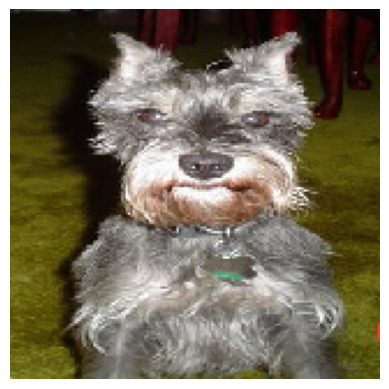

In [23]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = "/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/10005.jpg"

img = image.load_img(img_path, target_size=input_size)

plt.imshow(img)
plt.axis("off")

x = image.img_to_array(img)
x = x/255.
x = np.expand_dims(x, axis=0)

pred = loaded_model.predict(x)

if pred[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

In [21]:
# Hiển thị xác suất
prob = pred[0][0]

print(f"Dog: {prob*100:.2f}%")
print(f"Cat: {(1-prob)*100:.2f}%")

Dog: 0.00%
Cat: 100.00%


In [22]:
# Dự đoán nhiều ảnh
from glob import glob

test_images = glob("/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/**/*.jpg", recursive=True)

for img_path in test_images[:10]:

    img = image.load_img(img_path, target_size=input_size)

    x = image.img_to_array(img)
    x /= 255.
    x = np.expand_dims(x, axis=0)

    pred = loaded_model.predict(x, verbose=0)

    label = "Dog" if pred[0][0] > 0.5 else "Cat"

    print(img_path, "->", label)

/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/7981.jpg -> Dog
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/6234.jpg -> Dog
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/1269.jpg -> Dog
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/3863.jpg -> Dog
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/6241.jpg -> Dog
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/10304.jpg -> Dog
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/623.jpg -> Dog
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/2193.jpg -> Dog
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/11925.jpg -> Dog
/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset